In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 불러오기 완료')

라이브러리 불러오기 완료


In [2]:
data = load_breast_cancer()

In [3]:
feature_names = list(data.feature_names)
print('feature 개수:', len(feature_names))
print('앞쪽5개 feature 이름:', feature_names[:5])

feature 개수: 30
앞쪽5개 feature 이름: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]


In [4]:
feature_names + ['target']

[np.str_('mean radius'),
 np.str_('mean texture'),
 np.str_('mean perimeter'),
 np.str_('mean area'),
 np.str_('mean smoothness'),
 np.str_('mean compactness'),
 np.str_('mean concavity'),
 np.str_('mean concave points'),
 np.str_('mean symmetry'),
 np.str_('mean fractal dimension'),
 np.str_('radius error'),
 np.str_('texture error'),
 np.str_('perimeter error'),
 np.str_('area error'),
 np.str_('smoothness error'),
 np.str_('compactness error'),
 np.str_('concavity error'),
 np.str_('concave points error'),
 np.str_('symmetry error'),
 np.str_('fractal dimension error'),
 np.str_('worst radius'),
 np.str_('worst texture'),
 np.str_('worst perimeter'),
 np.str_('worst area'),
 np.str_('worst smoothness'),
 np.str_('worst compactness'),
 np.str_('worst concavity'),
 np.str_('worst concave points'),
 np.str_('worst symmetry'),
 np.str_('worst fractal dimension'),
 'target']

In [5]:
data = load_breast_cancer()

feature_names = list(data.feature_names)

print('feature 개수:', len(feature_names))
print(f'feature_names: {feature_names}')

feature 개수: 30
feature_names: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]


In [6]:
X = pd.DataFrame(data.data, columns = feature_names)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
X = pd.DataFrame(data.data, columns=feature_names)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
y_original = pd.Series(data.target, name = 'target_original')

y = 1 - y_original
y.name = 'target'

In [9]:
compare_label = pd.DataFrame({
    'target_original (0=악성, 1=양성)':y_original,
    'target(0=악성, 1=양성)':y
})
compare_label.head()

,"target_original (0=악성, 1=양성)","target(0=악성, 1=양성)"
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [10]:
y_original = pd.Series(data.target, name = 'target_original')
                      
y = 1 - y_original
y.name = 'target'

compare_label = pd.DataFrame({
    'target_original (0=악성, 1=양성)':y_original,
    'target(0=악성, 1=양성)':y
})
compare_label.head()

,"target_original (0=악성, 1=양성)","target(0=악성, 1=양성)"
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [11]:
label_to_name = {0:'benign', 1:'malignant'}

target_name = y.map(label_to_name)
target_name.name = 'target_name'

target_name.value_counts()

target_name
benign       357
malignant    212
Name: count, dtype: int64

In [12]:
target_name

0      malignant
1      malignant
2      malignant
3      malignant
4      malignant
         ...    
564    malignant
565    malignant
566    malignant
567    malignant
568       benign
Name: target_name, Length: 569, dtype: str

In [13]:
df=X.copy()

df['target'] = y.values
df['target_name'] = target_name.values

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,malignant


In [14]:
print('feature 컬럼만 선택한 표의 크기:', df[feature_names].shape)

print('feature + target 표의 크기:', df[feature_names + ['target']].shape)

feature 컬럼만 선택한 표의 크기: (569, 30)
feature + target 표의 크기: (569, 31)


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [16]:
missing_count = df.isnull().sum()

print(missing_count)

print('\n전체 결측치 총합:', missing_count.sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
target_name                0
dtype: int64

전체 결측치 총합: 0


In [17]:
count_by_class = df['target_name'].value_counts()
print('클래스별 개수')
print(count_by_class)

클래스별 개수
target_name
benign       357
malignant    212
Name: count, dtype: int64


In [18]:
ratio_by_class = df['target_name'].value_counts(normalize = True)
print('클래스별 비율')
print(ratio_by_class)

클래스별 비율
target_name
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


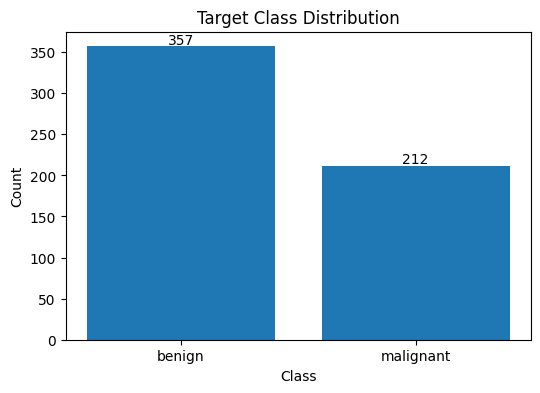

In [19]:
plt.figure(figsize = (6, 4))
plt.bar(count_by_class.index, count_by_class.values)

plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

for i, value in enumerate(count_by_class.values):
    plt.text(i, value + 3, str(value), ha = 'center')

plt.show()

In [20]:
df[feature_names].describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [21]:
mean_compare = df.groupby('target_name')[feature_names].mean().T

mean_compare['difference'] = (
    mean_compare['malignant'] - mean_compare['benign']
)

mean_compare['abs_difference'] = mean_compare['difference'].abs()

mean_compare.sort_values('abs_difference', ascending = False).head(15)

target_name,benign,malignant,difference,abs_difference
worst area,558.899440,1422.286321,863.386881,863.386881
mean area,462.790196,978.376415,515.586219,515.586219
worst perimeter,87.005938,141.370330,54.364392,54.364392
area error,21.135148,72.672406,51.537257,51.537257
mean perimeter,78.075406,115.365377,37.289971,37.289971
worst radius,13.379801,21.134811,7.755010,7.755010
worst texture,23.515070,29.318208,5.803138,5.803138
mean radius,12.146524,17.462830,5.316306,5.316306
mean texture,17.914762,21.604906,3.690144,3.690144
perimeter error,2.000321,4.323929,2.323608,2.323608


In [22]:
select_features = [
    'mean radius',
    'mean perimeter',
    'mean area',
    'mean concave points',
    'mean radius',
    'mean perimeter',
    'mean area',
    'worst concave points',
]

In [23]:
print('선택한 feature 개수:', len(select_features))
print('모든 데이터에 존재하는가?:', all(f in select_features for f in select_features))

선택한 feature 개수: 8
모든 데이터에 존재하는가?: True


In [24]:
benign_df = df[df['target_name'] == 'benign']
melignant_df = df[df['target_name'] == 'malignant']

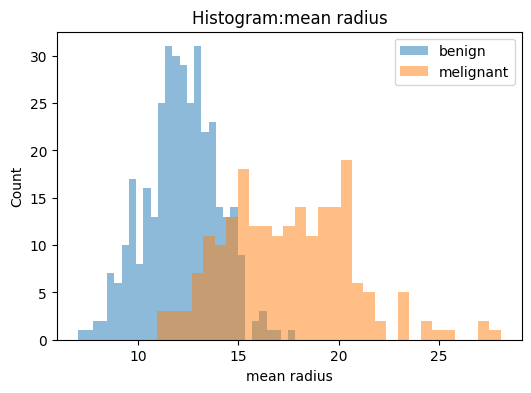

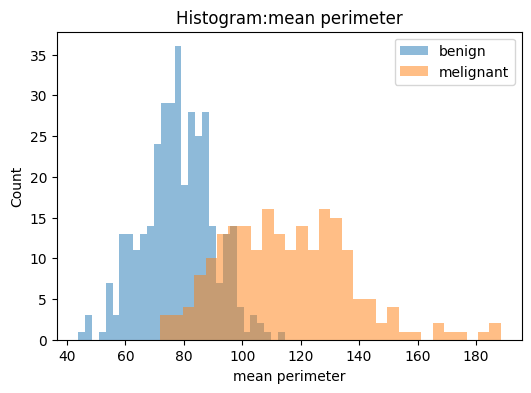

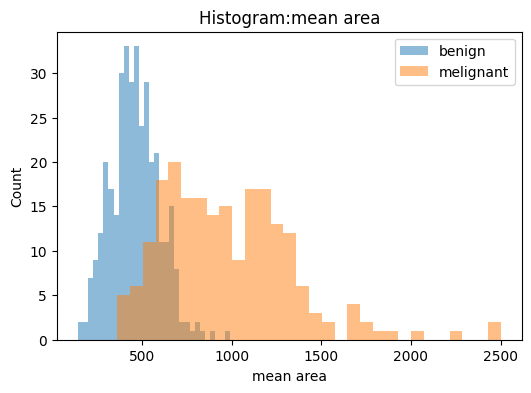

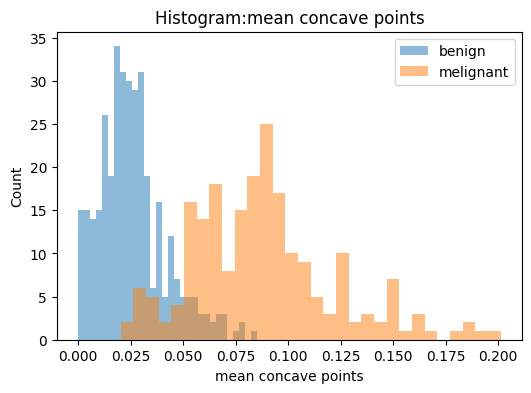

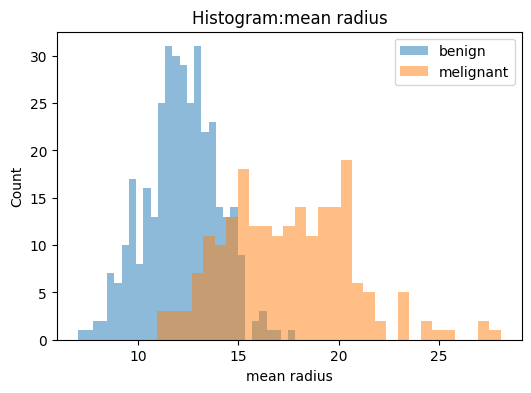

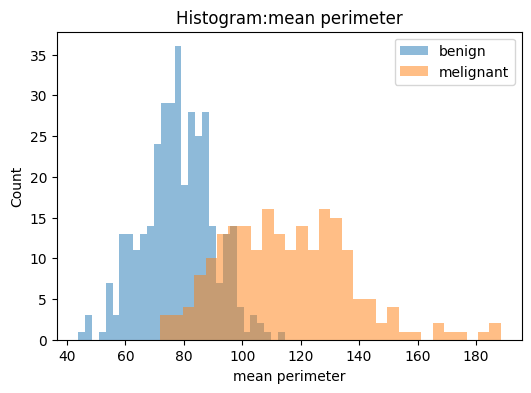

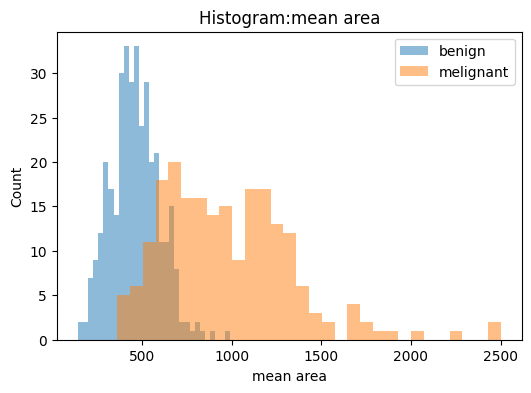

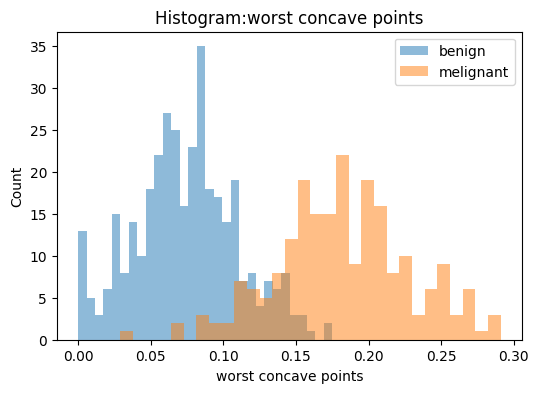

In [25]:
for feature in select_features:
    plt.figure(figsize=(6, 4))
    plt.hist(benign_df[feature], bins = 30, alpha = 0.5, label = 'benign')
    plt.hist(melignant_df[feature], bins = 30, alpha = 0.5, label = 'melignant')
    plt.title('Histogram:' + feature)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()
    plt.show()   

In [26]:
select_features = [
    'mean radius',
    'mean perimeter',
    'mean area',
    'mean concave points',
    'mean radius',
    'mean perimeter',
    'mean area',
    'worst concave points',
]

print('선택한 feature 개수:', len(select_features))
print('모든 데이터에 존재하는가?:', all(f in select_features for f in select_features))

선택한 feature 개수: 8
모든 데이터에 존재하는가?: True


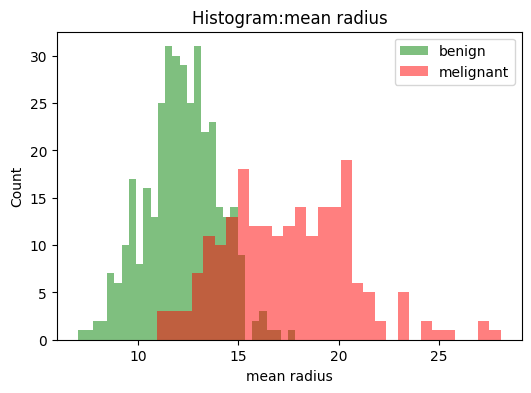

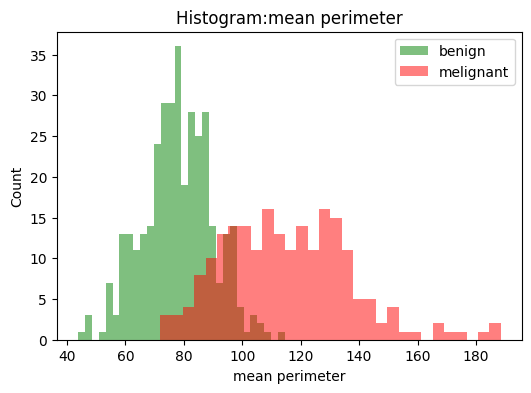

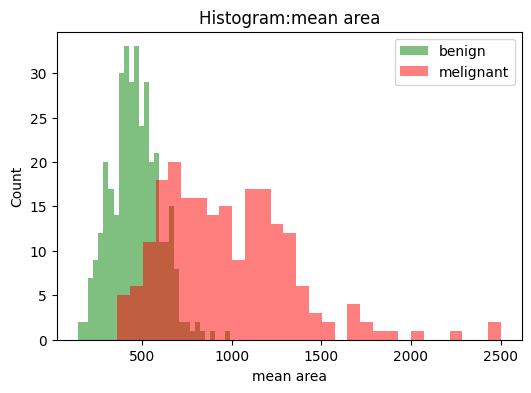

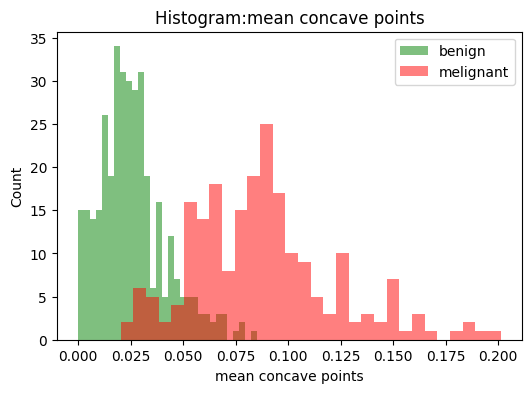

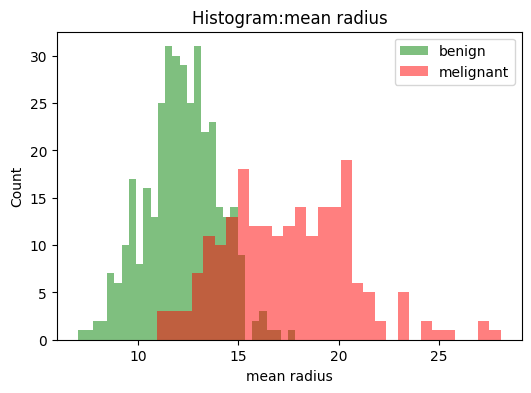

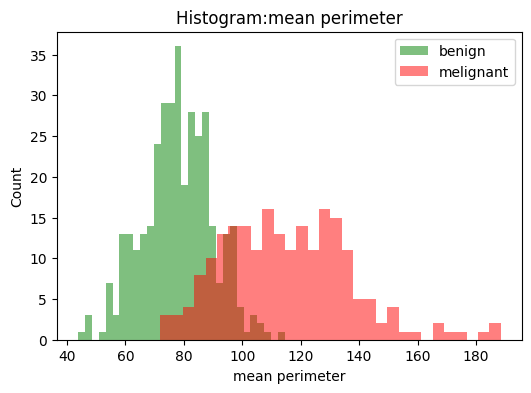

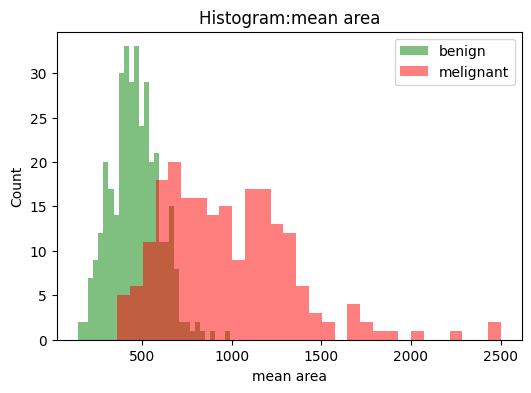

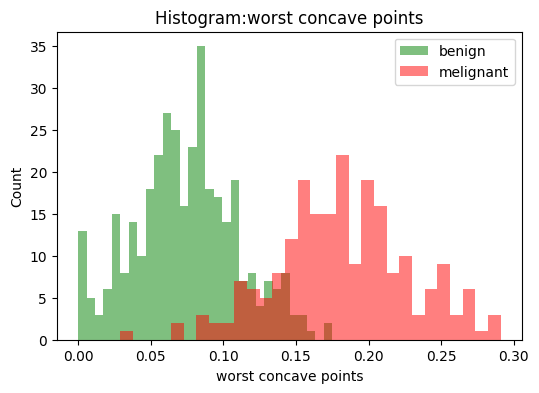

In [27]:
benign_df = df[df['target_name'] == 'benign']
malignant_df = df[df['target_name'] == 'malignant']

for feature in select_features:
    plt.figure(figsize=(6, 4))
    plt.hist(benign_df[feature], bins = 30, alpha = 0.5, label = 'benign', color = 'green')
    plt.hist(melignant_df[feature], bins = 30, alpha = 0.5, label = 'melignant', color = 'red')
    plt.title('Histogram:' + feature)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend()
    plt.show()   

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


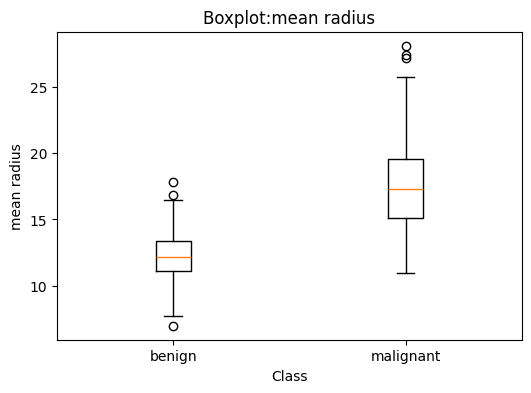

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


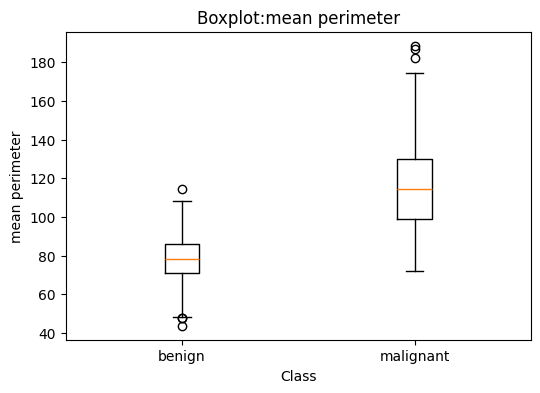

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


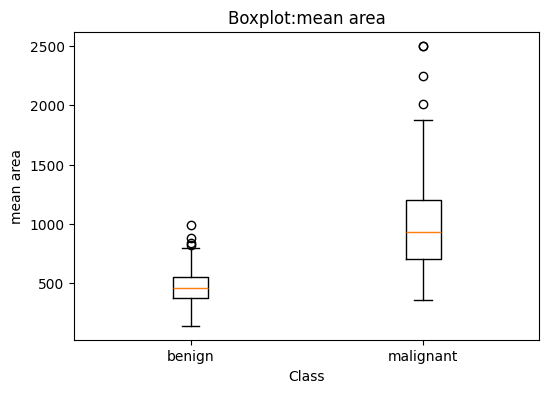

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


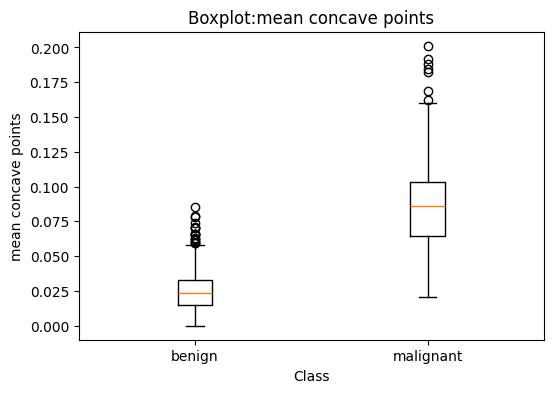

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


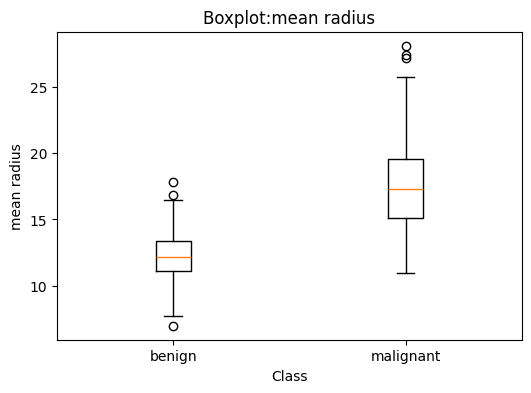

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


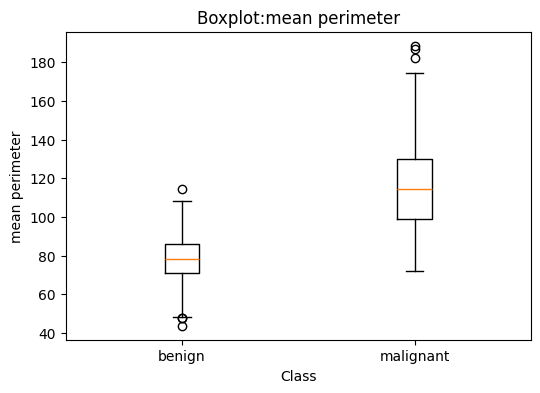

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


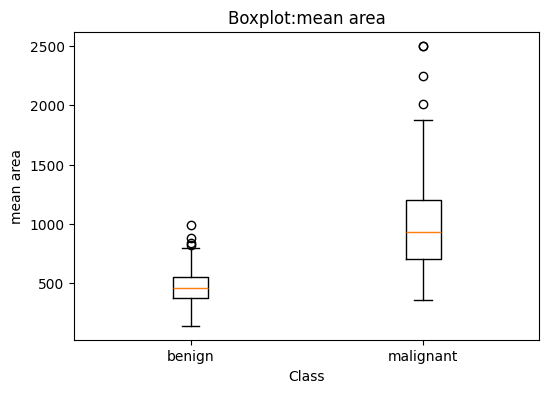

C:\Users\user\AppData\Local\Temp\ipykernel_4468\1791838613.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels = ['benign', 'malignant'])


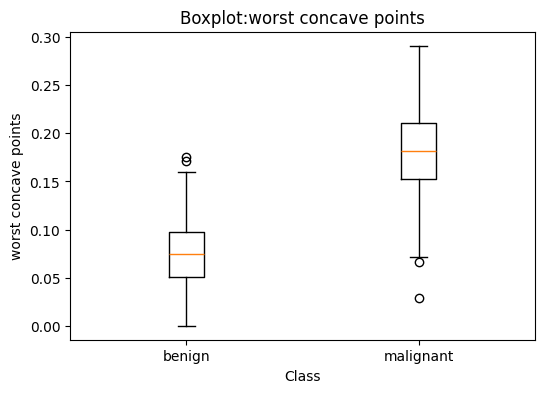

In [28]:
for feature in select_features:
    plt.figure(figsize=(6, 4))
    data_for_box = [benign_df[feature], malignant_df[feature]]
    plt.boxplot(data_for_box, labels = ['benign', 'malignant'])
    plt.title('Boxplot:' + feature)
    plt.xlabel('Class')
    plt.ylabel(feature)
    plt.show()   